# Experiment 4B — Queensland 2022 Betterment Fund Access
**Question:** among eligible council project applications, does pre-disaster capacity improve approval prediction beyond independently measured need?

**Result: CONDITIONAL GO for acquiring records; no model yet.** No verified eligible unsuccessful council applications or adequate two-outcome need block were recovered. This notebook audits that conclusion; it does not manufacture controls. All earlier experiments and outputs are preserved.

Read [the full report](results/FEASIBILITY_REPORT.md) for source-linked findings and [the dictionary](results/DATA_DICTIONARY.md) for definitions.

In [1]:
from pathlib import Path
import json, runpy
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "NSW Data Panel.csv").exists())
OUT = ROOT / "Experiment 4/related/betterment_access/results"
def read(name):
    return pd.read_csv(OUT / f"{name}.csv")
# Rebuild this audit from cached official sources and checked transcriptions only.
# The helper verifies all pre-existing files and does not load NSW values or fit models.
_ = runpy.run_path(str(ROOT / "Experiment 4/related/betterment_access/code/build_audit.py"))

{
  "existing_files_unchanged": 962,
  "reported_submissions": 123,
  "reported_council_applicants": 39,
  "published_rows": 221,
  "published_D_rows": 183,
  "published_E_rows": 38,
  "public_local_government_rows": 194,
  "public_state_agency_rows": 27,
  "award_councils": 38,
  "repeated_label_groups": 4,
  "distinct_published_labels": 217,
  "capacity_councils": 39,
  "capacity_numeric_values": 130,
  "known_eligible_unsuccessful_localgov_2022": 0,
  "model_ready_applications": 0,
  "models_fitted": 0,
  "overall_verdict": "CONDITIONAL GO \u2014 data acquisition only"
}


## 1. Resolve the observation before counting outcomes
QRA reports **123 submissions** from **39 councils and TMR**, often with multiple projects. Its award list has **221 asset/works rows**. These are different units. Our intended observation is one project application with parent submission and revisions linked. Public row IDs below are audit references, not official IDs; repeated labels are retained.

In [2]:
display(read("decision_universe_reconciliation")[["quantity", "value", "unit", "caveat"]])
awards = read("published_approved_projects")
display(awards[["funding_stream", "applicant", "project_asset_label", "status"]].head(6))
display(read("repeated_project_labels")[["applicant", "project_asset_label", "same_label_row_count"]].drop_duplicates())

,quantity,value,unit,caveat
0,Reported submissions,123,Submission; may contain multiple projects,QRA program status; not project denominator
1,Reported council applicants,39,Councils,TMR also submitted; identities of all submitte...
2,Published approved asset/works rows,221,Public-list rows,Keep repeats; does not equal unique projects
3,Published local-government approved rows,194,Public-list rows,Excludes state agency
4,Distinct approved council names,38,Councils,Not the number of independent applications
5,Distinct stream/applicant/asset labels,217,Labels,Not certified deduplicated project count
6,Verified eligible unsuccessful local-governmen...,0,Cases recovered by this audit,Unknown population count; not evidence all app...
7,Application IDs recovered,0,Official IDs,Public row IDs are audit references only
8,Model-ready application observations,0,Certified observations,No valid two-class risk set or need block


,funding_stream,applicant,project_asset_label,status
0,D,Balonne Shire Council,Mungindi Levee,APPROVED_REPORTED
1,D,Balonne Shire Council,Whyenbah Road,APPROVED_REPORTED
2,D,Balonne Shire Council,Jakelwar-Goodooga Road North,APPROVED_REPORTED
3,D,Balonne Shire Council,Jakelwar-Goodooga Road North,APPROVED_REPORTED
4,D,Banana Shire Council,Defence Road,APPROVED_REPORTED
5,D,Banana Shire Council,Coolum Road,APPROVED_REPORTED


,applicant,project_asset_label,same_label_row_count
0,Balonne Shire Council,Jakelwar-Goodooga Road North,2
2,Department of Transport and Main Roads,Moonie Highway,2
3,Department of Transport and Main Roads,Burnett Highway,2
6,South Burnett Regional Council,Noroads Road,2


## 2. Search for an eligible unsuccessful comparison group
Boulia supplies explicit **ineligibility**, not an eligible rejection. TMR cases are state-agency proposals; Somerset is an older round. Ipswich is lodged/unresolved. Repeated status observations are not new applications. Absence from the award list never means unsuccessful.

Every observation has a URL, page/section and confidence in the saved ledger. The [search log](results/search_and_negative_findings.csv) records limits and rejected leads; zero recovered cases does not establish zero unsuccessful cases in the population.

,evidence_id,applicant,reported_status,round_scope,usable_eligible_negative
0,B01,Boulia Shire Council,INELIGIBLE,2021–22 event; consistent with Category E scop...,False
1,B02,Boulia Shire Council,UNRESOLVED_LODGED,2021–22 event; consistent with Category E scop...,False
2,B03,Boulia Shire Council,UNRESOLVED_LODGED,2021–22 event; earlier observation of B01,False
3,B04,Boulia Shire Council,INELIGIBLE,2021–22 event; repeat observation of B01,False
4,D01,Department of Transport and Main Roads,UNSUCCESSFUL_REPORTED,FUNDING_ROUND_UNVERIFIED; state-agency applica...,False
5,D02,Department of Transport and Main Roads,UNSUCCESSFUL_REPORTED,FUNDING_ROUND_UNVERIFIED; state-agency applica...,False
6,I01,Ipswich City Council,UNRESOLVED_LODGED,2022 flood recovery context; Betterment round/...,False
7,M01,Mareeba Shire Council,REJECTED_REINSTATEMENT,BETTERMENT_2022_MEMBERSHIP_UNVERIFIED,False
8,S01,Somerset Regional Council,UNSUCCESSFUL_REPORTED,EXCLUDED_2015_CYCLONE_MARCIA_ROUND,False
9,S02,Scenic Rim Regional Council,UNRESOLVED_UNDER_ASSESSMENT,Four recovery events incl March 2021 and 2021–...,False


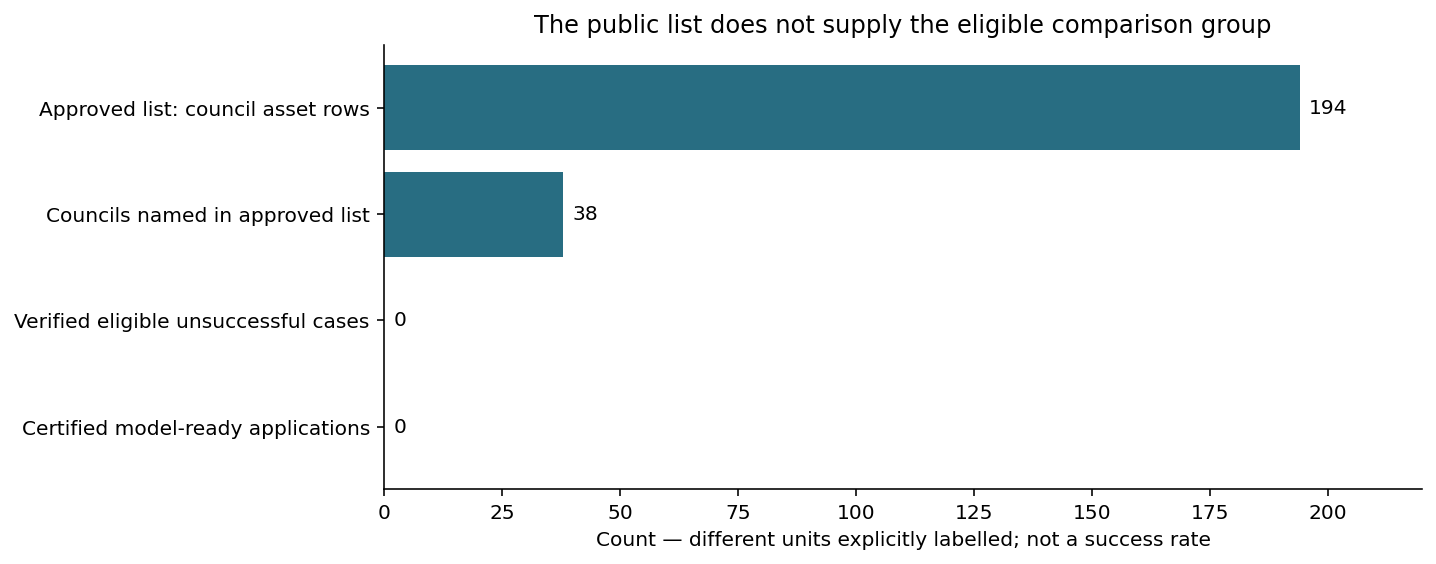

In [3]:
evidence = read("decision_evidence")
display(evidence[["evidence_id", "applicant", "reported_status", "round_scope", "usable_eligible_negative"]])
assert not evidence["usable_eligible_negative"].any()
display(Image(filename=str(OUT / "figures/03_decision_gap.png")))

## 3. Capacity exists, but timing and definitions matter
Three QAO ratios were recovered for 39 identified councils (38 award-list councils plus Boulia). Most refer to 2020–21; Palm Island and Richmond use 2019–20. QAO published them on **11 May 2022**, after some disasters. Measurement timing and public availability are separate tests. Brisbane's accounting change is flagged.

The grant measure is a five-year average; net financial liabilities are not simply debt. An Ipswich pilot adds cash, revenue components, staffing and scale, without claiming statewide comparability. No NSW substitutes or composite capacity index are used.

In [4]:
display(read("capacity_data_availability")[["capacity_block", "councils_with_pilot_values", "remaining_gap"]])
capacity = read("queensland_capacity_values")
print(f"{len(capacity)} numeric values; {capacity.council_key.nunique()} identified councils")
time_audit = read("temporal_availability_audit")
display(time_audit.groupby("timing_verdict", dropna=False).size().rename("award rows").to_frame())
display(capacity.loc[capacity.council_name.str.contains("Palm Island|Richmond|Brisbane"),
                     ["council_name", "feature", "value", "measurement_date", "quality_note"]])

,capacity_block,councils_with_pilot_values,remaining_gap
0,operating position,39,Pre-event values recovered; report published 1...
1,liquidity/cash,1,Pilot only; unrestricted liquidity not yet com...
2,own-source revenue,1,Pilot components; no complete comparable own-s...
3,grant dependence,39,Recovered proxy; differs from current operatin...
4,debt burden/capacity,39,Recovered; Brisbane concession accounting and ...
5,staffing/administrative scale,1,Pilot only; headcount is not FTE or dedicated ...
6,population/infrastructure scale,1,"Pilot only; ABS ERP, road length and consisten..."
7,prior disaster/grant experience,0,No complete pre-cutoff application history rec...


130 numeric values; 39 identified councils


,award rows
timing_verdict,
APPLICATION/DECISION DATE UNKNOWN; no strict as-of join certified,193
QAO baseline predates earliest day of reported submission month,1


,council_name,feature,value,measurement_date,quality_note
18,Brisbane City Council,grant_share_5yr_pct,12.00,2021-06-30,2020–21 ratios; AASB1059 concession liabilitie...
19,Brisbane City Council,operating_surplus_pct,1.00,2021-06-30,2020–21 ratios; AASB1059 concession liabilitie...
20,Brisbane City Council,net_financial_liabilities_pct,202.00,2021-06-30,2020–21 ratios; AASB1059 concession liabilitie...
84,Palm Island Aboriginal Shire Council,grant_share_5yr_pct,54.00,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...
85,Palm Island Aboriginal Shire Council,operating_surplus_pct,-23.80,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...
86,Palm Island Aboriginal Shire Council,net_financial_liabilities_pct,-2.93,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...
93,Richmond Shire Council,grant_share_5yr_pct,60.00,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...
94,Richmond Shire Council,operating_surplus_pct,-12.67,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...
95,Richmond Shire Council,net_financial_liabilities_pct,4.25,2020-06-30,QAO footnote: 2020–21 audit unfinished; ratios...


## 4. Need must reflect the assessment criteria
The guidelines require risk/options, cost-benefit, community benefits and technical evidence. A comparable project-level block across both outcomes is missing. Selected success stories, realised benefits and post-approval design changes cannot replace original need. No arbitrary need index is constructed.

Scores/recommendations are requested to audit the process; an approval recommendation would leak the outcome if used as a predictor. Underlying damage should be distinguished from the presentation quality of a council's application.

In [5]:
display(read("project_need_quality_audit")[["variable", "policy_locator", "public_recovery_status"]])
display(read("policy_and_unit_audit")[["stream", "rule_or_change", "analytical_implication"]])

,variable,policy_locator,public_recovery_status
0,damage_reconstruction_estimate,Eligibility §§6–7; funding §11,None across certified application universe; Bo...
1,requested_betterment_and_total_cost,Funding §§11–17; assessment b,Ipswich bundled requested REPA value only; not...
2,hazard_risk_options,Assessment a,Application dossiers not public in reviewed so...
3,cost_benefit_bcr,Assessment b,No application-specific BCR or assessor score ...
4,community_benefit,Assessment c,Retrospective selected-success narratives only...
5,vulnerability_remoteness,Prioritisation §19,No project footprints/beneficiary records; cou...
6,asset_project_type,Eligibility §7; assessment a/d,221 public asset labels; formal class/scope an...
7,deliverability_technical_evidence,Assessment d; application §27; §28 is post-app...,No full original application evidence for both...
8,innovation,Assessment e,Not recovered consistently
9,regional_balance_other_funding,Prioritisation §19,Not recovered at application level


,stream,rule_or_change,analytical_implication
0,2022 D,3 events in June; May flooding added in July,Verify guideline/annex version at each decision
1,2022 E,9 listed 2021–22 events,"Separate stream, allocation pool and project cap"
2,Both,CEO QRA final project approval; unsuccessful p...,Do not treat temporary non-approval as final o...
3,Both,Co-contribution normally required; Indigenous ...,Record rule; council capacity and contribution...
4,Both,MARS withdrawal/re-lodgement can be an adminis...,Track parent/revision identifiers; do not coun...
5,2022 fund,Later funding reallocation reported,Not initial allocation or project approval; ne...


## 5. Apply the gates — stop before modelling
Public award rows cluster within councils; they are not independent replications of council capacity. No logistic regression or tree is fitted because the eligible outcome universe and need block fail the gates. A larger approved-only dataset would not solve this problem.

,gate,question,verdict,evidence
0,1,Eligible approved applications identifiable,PARTIAL,Official award labels for 194 council asset/wo...
1,2,Eligible unsuccessful applications identifiable,NOT PASSED,Zero verified eligible unsuccessful 2022 local...
2,3,Consistent outcome across applications,NOT PASSED,"Need unique projects, eligibility, decision cu..."
3,4,Enough outcomes across distinct councils,NOT PASSED,No certified negative councils; 38 award counc...
4,5,Independent need/project quality adequate,NOT PASSED,"Criteria known, application-level damage/CBA/q..."
5,6,Comparable pre-decision capacity available,PARTIAL,Three QAO measures recovered for 39 identified...


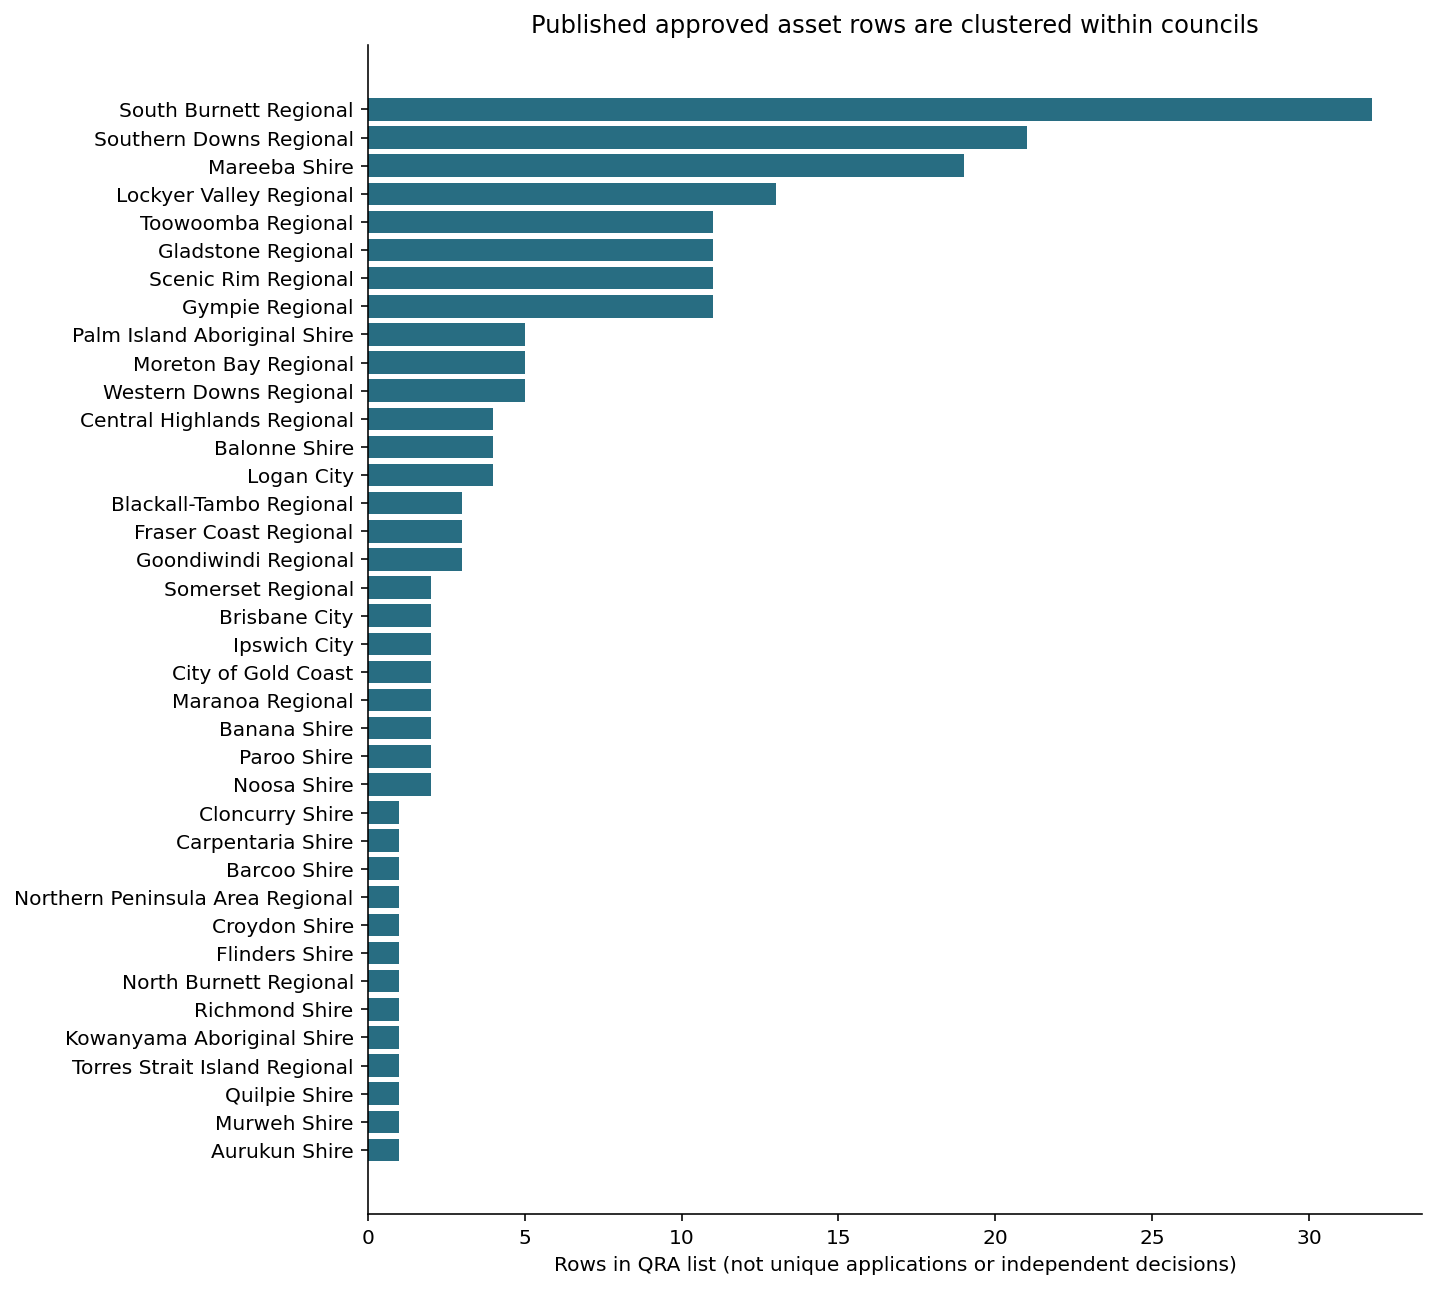

All 962 pre-existing files unchanged. No model fitted.


In [6]:
display(read("feasibility_gates"))
display(Image(filename=str(OUT / "figures/01_council_clustering.png")))
checks = json.loads((OUT / "validation_checks.json").read_text())
assert checks["models_fitted"] == 0
assert checks["existing_files_unchanged"] == 962
print("All 962 pre-existing files unchanged. No model fitted.")

## 6. What would justify continuing?
Obtain the [QRA data-request draft](results/QRA_DATA_REQUEST.md) (**not sent**): full project/submission identifiers, eligibility and status histories, dates and amounts, original need evidence, assessment measures and non-approval reasons. Reconcile the application universe first.

Only if all gates subsequently pass: compare M0 need-only against M1 need-plus-capacity using logistic regression and a depth-2/3 tree. Hold out whole councils; fit preprocessing only on training councils. Use paired held-out log loss/Brier score, calibration and defined discrimination metrics, with uncertainty clustered by council. Keep all valid folds and report undefined metrics honestly. Whole-council validation is not future-year validation. Predictive contribution would not prove discrimination or causation.

| Feasibility component | Verdict |
|---|---|
| Decision data | CONDITIONAL GO — QRA registry required |
| Queensland capacity | CONDITIONAL GO — core ratios recovered, broader panel/timing incomplete |
| Need measurement | CONDITIONAL GO — original comparable evidence required |
| Modelling | NO-GO now — gates not passed |
| Overall Experiment 4B | **CONDITIONAL GO for data acquisition only** |

No predictive performance is reported because no defensible model can yet be evaluated.